# Lab 1 — PCA y monitoreo estructural (SHM)

## Carga de datos

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid")

In [7]:
RUTA_DATOS = Path("data/building_health_monitoring_dataset.csv")
df = pd.read_csv(RUTA_DATOS, parse_dates=["Timestamp"])
print(f"Archivo: {RUTA_DATOS} | Forma: {df.shape[0]} filas × {df.shape[1]} columnas")

FEATURES = [
    "Accel_X (m/s^2)",
    "Accel_Y (m/s^2)",
    "Accel_Z (m/s^2)",
    "Strain (με)",
    "Temp (°C)",
]
N_FILAS_HEAD = 5
print(f"Features para PCA: {FEATURES}")
print(f"Primeras {N_FILAS_HEAD} lecturas:")
display(df.head(N_FILAS_HEAD))

Archivo: data\building_health_monitoring_dataset.csv | Forma: 1000 filas × 7 columnas
Features para PCA: ['Accel_X (m/s^2)', 'Accel_Y (m/s^2)', 'Accel_Z (m/s^2)', 'Strain (με)', 'Temp (°C)']
Primeras 5 lecturas:


,Timestamp,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C),Condition Label
0,2025-04-19 00:00:00,0.149014,0.419807,9.742482,61.843849,23.704760,0
1,2025-04-19 00:00:01,-0.041479,0.277390,9.795548,82.792300,24.953195,0
2,2025-04-19 00:00:02,0.194307,0.017889,9.730758,91.727889,25.027025,0
3,2025-04-19 00:00:03,0.456909,-0.194081,9.779204,137.753753,25.708946,0
4,2025-04-19 00:00:04,-0.070246,0.209467,9.620639,111.131062,22.949712,0


## Calidad de datos

Revisamos tipos, duplicados, continuidad temporal y valores nulos antes de limpiar.

In [8]:
ETIQUETA = "Condition Label"
NOMBRES_CLASE = {0: "Normal", 1: "Daño menor", 2: "Daño severo"}

print("Tipos de dato:")
display(df.dtypes)
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"Timestamps duplicados: {df['Timestamp'].duplicated().sum()}")
print("Intervalo entre lecturas:")
display(df["Timestamp"].diff().value_counts())

Tipos de dato:


Timestamp          datetime64[us]
Accel_X (m/s^2)           float64
Accel_Y (m/s^2)           float64
Accel_Z (m/s^2)           float64
Strain (με)               float64
Temp (°C)                 float64
Condition Label             int64
dtype: object

Filas duplicadas: 0
Timestamps duplicados: 0
Intervalo entre lecturas:


Timestamp
0 days 00:00:01    999
Name: count, dtype: int64

In [9]:
mask_nulos = df[FEATURES].isna()
print("Nulos por sensor:")
display(mask_nulos.sum())

filas_con_nulo = mask_nulos.any(axis=1)
print(f"Filas con al menos un nulo: {filas_con_nulo.sum()} ({filas_con_nulo.mean():.1%})")
print("Nº de sensores nulos por fila:")
display(mask_nulos.sum(axis=1).value_counts().sort_index())

print("¿Los nulos dependen de la clase? (% de filas con nulo por clase)")
display(filas_con_nulo.groupby(df[ETIQUETA]).mean().rename(NOMBRES_CLASE).map("{:.1%}".format))

Nulos por sensor:


Accel_X (m/s^2)    20
Accel_Y (m/s^2)    20
Accel_Z (m/s^2)    20
Strain (με)        20
Temp (°C)          20
dtype: int64

Filas con al menos un nulo: 96 (9.6%)
Nº de sensores nulos por fila:


0    904
1     92
2      4
Name: count, dtype: int64

¿Los nulos dependen de la clase? (% de filas con nulo por clase)


Condition Label
Normal         9.5%
Daño menor     9.8%
Daño severo    9.7%
dtype: str

## Limpieza

Decisiones:

- **Nulos → eliminar filas (`dropna`).** Cada fila afectada pierde solo 1–2 sensores y la proporción de nulos es similar en las tres clases, así que al eliminarlas no se sesga la distribución de etiquetas.
  - No imputamos por clase porque eso usaría la etiqueta y filtraría información al PCA/clustering.
  - Tampoco interpolamos en el tiempo, porque la etiqueta cambia casi cada 2 lecturas y mezclaríamos estados distintos.
- **Duplicados:** no hay.
- **Outliers → se conservan.** Más abajo se ve que se concentran en la clase de daño severo: son señal, no ruido.

In [10]:
n_antes = len(df)
df_limpio = df.dropna(subset=FEATURES).drop_duplicates().reset_index(drop=True)
print(f"Tras limpieza: {n_antes} → {len(df_limpio)} lecturas válidas ({n_antes - len(df_limpio)} eliminadas)")

comparacion_clases = pd.DataFrame({
    "Antes": df[ETIQUETA].value_counts(normalize=True),
    "Después": df_limpio[ETIQUETA].value_counts(normalize=True),
}).rename(index=NOMBRES_CLASE).round(3)
print("Proporción de clases antes y después de limpiar:")
display(comparacion_clases)

Tras limpieza: 1000 → 904 lecturas válidas (96 eliminadas)
Proporción de clases antes y después de limpiar:


,Antes,Después
Condition Label,,
Normal,0.704,0.705
Daño menor,0.183,0.183
Daño severo,0.113,0.113


## EDA

### Estadísticas descriptivas

In [11]:
resumen = df_limpio[FEATURES].describe().T
resumen["cv"] = resumen["std"] / resumen["mean"].abs()
display(resumen.round(3))

,count,mean,std,min,25%,50%,75%,max,cv
Accel_X (m/s^2),904.0,0.106,0.341,-0.795,-0.139,0.084,0.303,1.338,3.231
Accel_Y (m/s^2),904.0,0.017,0.298,-0.882,-0.183,0.013,0.218,0.941,17.639
Accel_Z (m/s^2),904.0,9.812,0.097,9.508,9.747,9.810,9.875,10.203,0.010
Strain (με),904.0,111.889,28.658,41.860,92.534,108.961,127.945,224.862,0.256
Temp (°C),904.0,25.034,1.518,20.244,24.024,25.060,26.051,29.839,0.061


### Distribución de clases

,n,%
Condition Label,,
Normal,637,70.5
Daño menor,165,18.3
Daño severo,102,11.3


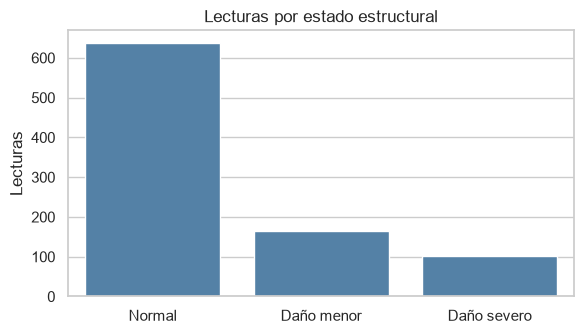

In [12]:
conteo = df_limpio[ETIQUETA].value_counts().sort_index()
display(pd.DataFrame({"n": conteo, "%": (conteo / conteo.sum() * 100).round(1)}).rename(index=NOMBRES_CLASE))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(data=df_limpio, x=ETIQUETA, ax=ax, color="steelblue")
ax.set_xticks(range(len(NOMBRES_CLASE)), NOMBRES_CLASE.values())
ax.set_xlabel("")
ax.set_ylabel("Lecturas")
ax.set_title("Lecturas por estado estructural")
plt.tight_layout()
plt.show()

### Distribución de cada sensor por clase

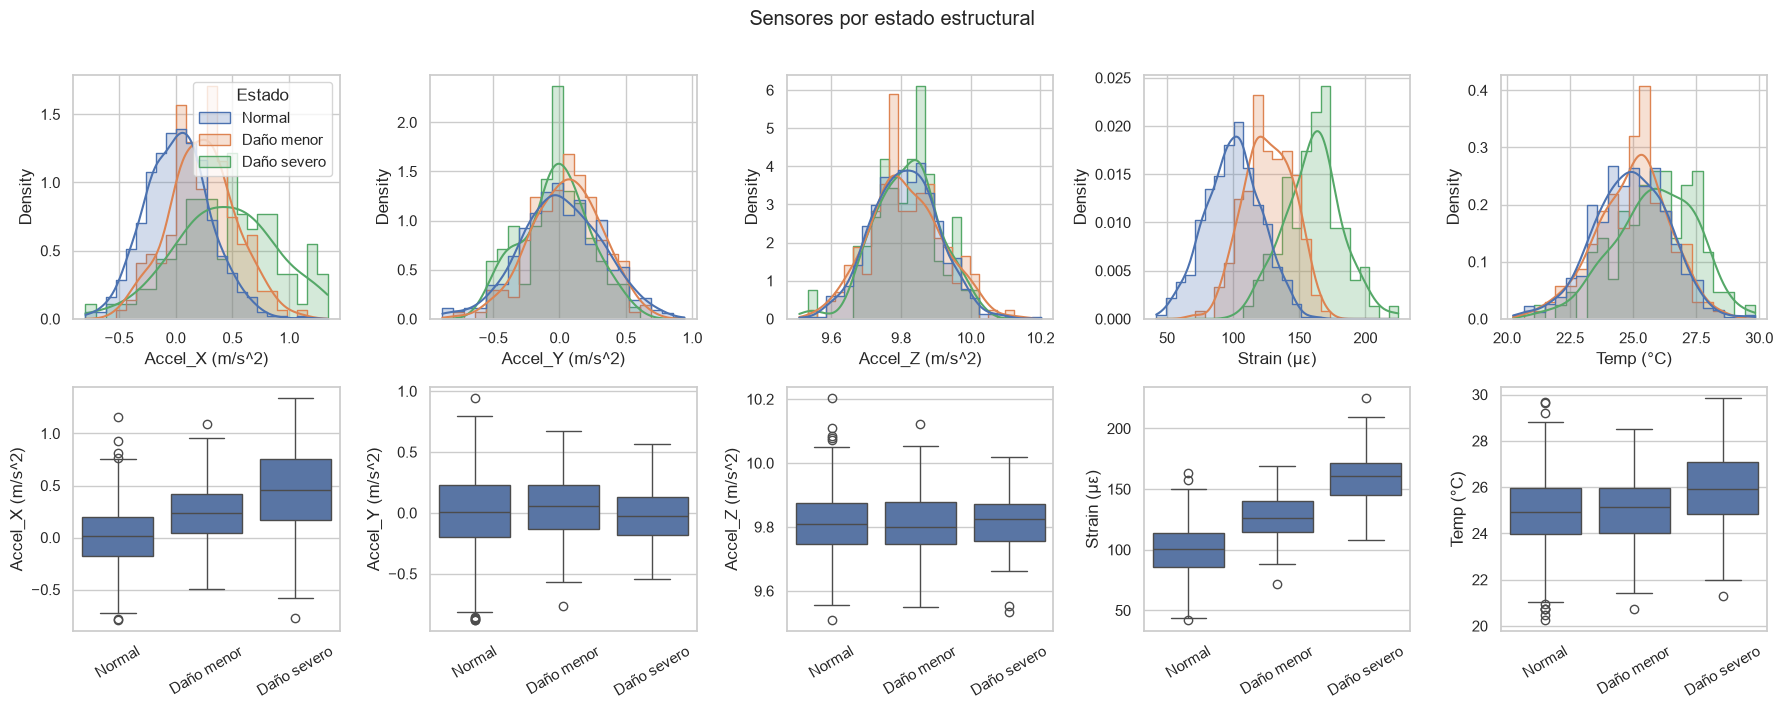

Media de cada sensor por clase:


,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C)
Condition Label,,,,,
Normal,0.019,0.016,9.811,100.252,24.916
Daño menor,0.235,0.049,9.813,126.849,24.977
Daño severo,0.438,-0.028,9.818,160.360,25.865


In [13]:
df_plot = df_limpio.assign(Estado=df_limpio[ETIQUETA].map(NOMBRES_CLASE))
fig, axes = plt.subplots(2, len(FEATURES), figsize=(18, 7))
for i, col in enumerate(FEATURES):
    sns.histplot(data=df_plot, x=col, hue="Estado", kde=True, element="step",
                 stat="density", common_norm=False, ax=axes[0, i], legend=(i == 0))
    sns.boxplot(data=df_plot, x="Estado", y=col, ax=axes[1, i], order=NOMBRES_CLASE.values())
    axes[1, i].set_xlabel("")
    axes[1, i].tick_params(axis="x", rotation=30)
plt.suptitle("Sensores por estado estructural", y=1.01)
plt.tight_layout()
plt.show()

print("Media de cada sensor por clase:")
display(df_limpio.groupby(ETIQUETA)[FEATURES].mean().rename(index=NOMBRES_CLASE).round(3))

### Correlaciones

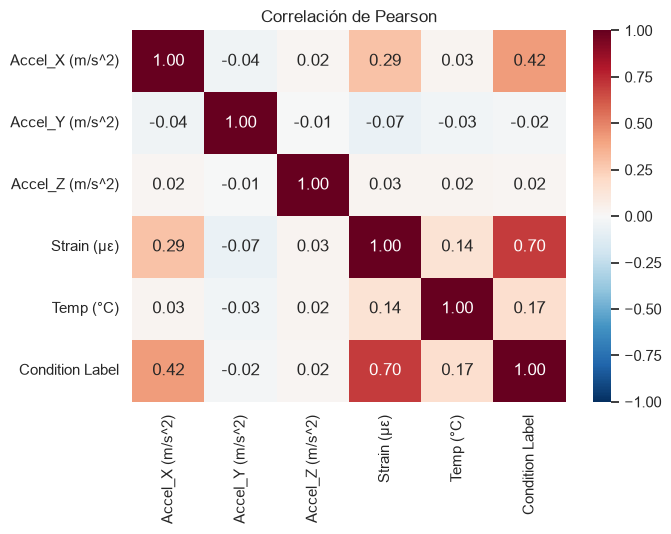

Top 3 pares de sensores por |r|:


Accel_X (m/s^2)  Strain (με)    0.290
Strain (με)      Temp (°C)      0.144
Accel_Y (m/s^2)  Strain (με)   -0.070
dtype: float64

Correlación de cada sensor con la etiqueta:


Strain (με)        0.698
Accel_X (m/s^2)    0.424
Temp (°C)          0.171
Accel_Y (m/s^2)   -0.021
Accel_Z (m/s^2)    0.020
Name: Condition Label, dtype: float64

In [14]:
corr = df_limpio[FEATURES + [ETIQUETA]].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Pearson")
plt.tight_layout()
plt.show()

TOP_N_CORR = 3
pares = corr.loc[FEATURES, FEATURES].where(np.triu(np.ones((len(FEATURES),) * 2, dtype=bool), k=1)).stack()
print(f"Top {TOP_N_CORR} pares de sensores por |r|:")
display(pares.reindex(pares.abs().sort_values(ascending=False).index).head(TOP_N_CORR).round(3))
print("Correlación de cada sensor con la etiqueta:")
display(corr.loc[FEATURES, ETIQUETA].sort_values(key=abs, ascending=False).round(3))

### Outliers (criterio IQR 1.5×)

In [15]:
q1, q3 = df_limpio[FEATURES].quantile(0.25), df_limpio[FEATURES].quantile(0.75)
iqr = q3 - q1
mask_out = (df_limpio[FEATURES] < q1 - 1.5 * iqr) | (df_limpio[FEATURES] > q3 + 1.5 * iqr)
print("Outliers por sensor:")
display(mask_out.sum())

es_outlier = mask_out.any(axis=1)
print(f"Filas con algún outlier: {es_outlier.sum()} ({es_outlier.mean():.1%})")
reparto = pd.DataFrame({
    "% del dataset": df_limpio[ETIQUETA].value_counts(normalize=True),
    "% de los outliers": df_limpio.loc[es_outlier, ETIQUETA].value_counts(normalize=True),
}).rename(index=NOMBRES_CLASE).mul(100).round(1)
display(reparto)

Outliers por sensor:


Accel_X (m/s^2)    15
Accel_Y (m/s^2)     7
Accel_Z (m/s^2)    10
Strain (με)        15
Temp (°C)          11
dtype: int64

Filas con algún outlier: 55 (6.1%)


,% del dataset,% de los outliers
Condition Label,,
Normal,70.5,41.8
Daño menor,18.3,7.3
Daño severo,11.3,50.9


## Insights

**1. `Strain` es el sensor que mejor delata el daño; `Accel_X` es el segundo.**
- La deformación media sube de forma monótona: Normal ≈ 100 με → Daño menor ≈ 127 με → Daño severo ≈ 160 με.
- Su correlación con la etiqueta es r = 0.70. La de `Accel_X` es r = 0.42 (media 0.02 → 0.24 → 0.44 m/s²).
- `Accel_Y` y `Accel_Z` no cambian entre clases (|r| ≈ 0.02). `Accel_Z` es prácticamente la gravedad (9.81 ± 0.10 m/s²).
- En obra: un extensómetro y la vibración lateral en X serían la primera alerta de daño.

**2. Los outliers no son ruido: la mitad corresponde a daño severo.**
- La clase "Daño severo" es el 11% de las lecturas, pero aporta el 51% de las filas con valores atípicos (IQR 1.5×).
- Eliminarlos borraría justo los eventos que interesa detectar. Por eso se conservan y se usa `StandardScaler` en lugar de recortar.
- Los nulos, en cambio, sí son aleatorios: ~9.6% en cada clase. Eliminarlos no cambia la proporción de clases (70.5 / 18.3 / 11.3%).

**3. Los sensores apenas son redundantes, así que PCA comprimirá poco.**
- La correlación más alta entre sensores es `Accel_X`–`Strain` con r = 0.29. El resto tiene |r| < 0.15.
- Sin redundancia, la varianza se reparte casi por igual entre las componentes. Una comprobación rápida da PC1 ≈ 27% y el resto ≈ 14–20% cada una.
- PC1 + PC2 retienen solo ~47% de la información, así que la proyección 2D será una vista parcial. Hacen falta 4 componentes para llegar a ~86%.
- A esto se suma el desbalance (70% Normal): KMeans y DBSCAN probablemente no recuperarán las 3 clases limpiamente. Conviene esperar un ARI modesto y usar `stratify` al dividir train/test.

## PCA sobre las variables más importantes

Según el EDA, los sensores con señal son `Strain`, `Accel_X` y `Temp`. `Accel_Y` y `Accel_Z` tienen |r| ≈ 0.02 con la etiqueta y solo añadirían ruido.

> Nota: esta selección se apoyó en la correlación con `Condition Label`, así que ya usa información de la etiqueta. El PCA en sí sigue siendo no supervisado, pero conviene tenerlo presente al interpretar los resultados.

Escalamos con `StandardScaler`: `Strain` (~100 με) dominaría a `Accel_X` (~0.1 m/s²) si no lo hiciéramos.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score

FEATURES_TOP = ["Strain (με)", "Accel_X (m/s^2)", "Temp (°C)"]
PALETA_CLASES = {0: "#2a9d8f", 1: "#e9c46a", 2: "#e63946"}

X_scaled = StandardScaler().fit_transform(df_limpio[FEATURES_TOP])
y = df_limpio[ETIQUETA].values
print(f"X_scaled: {X_scaled.shape}")

X_scaled: (904, 3)


### Varianza explicada

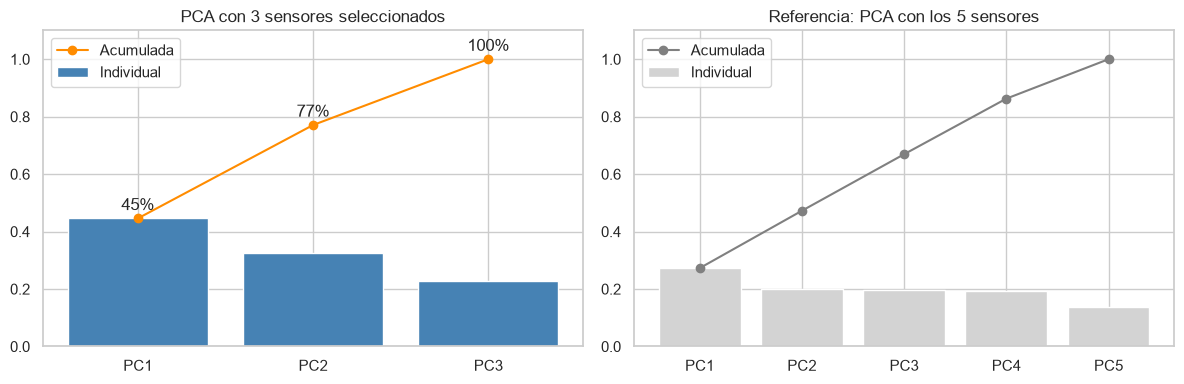

PC1+PC2 con 3 sensores: 77.1%  |  con 5 sensores: 47.2%


In [17]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_
var_acum = var_ratio.cumsum()

# Referencia: mismo PCA con los 5 sensores
var_ratio_5 = PCA().fit(StandardScaler().fit_transform(df_limpio[FEATURES])).explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pcs = [f"PC{i+1}" for i in range(len(var_ratio))]
axes[0].bar(pcs, var_ratio, color="steelblue", label="Individual")
axes[0].plot(pcs, var_acum, "o-", color="darkorange", label="Acumulada")
for i, v in enumerate(var_acum):
    axes[0].annotate(f"{v:.0%}", (i, v), textcoords="offset points", xytext=(0, 6), ha="center")
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f"PCA con {len(FEATURES_TOP)} sensores seleccionados")
axes[0].legend()

pcs5 = [f"PC{i+1}" for i in range(len(var_ratio_5))]
axes[1].bar(pcs5, var_ratio_5, color="lightgray", label="Individual")
axes[1].plot(pcs5, var_ratio_5.cumsum(), "o-", color="gray", label="Acumulada")
axes[1].set_ylim(0, 1.1)
axes[1].set_title(f"Referencia: PCA con los {len(FEATURES)} sensores")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"PC1+PC2 con {len(FEATURES_TOP)} sensores: {var_acum[1]:.1%}  |  con {len(FEATURES)} sensores: {var_ratio_5[:2].sum():.1%}")

### Loadings: qué representa cada componente

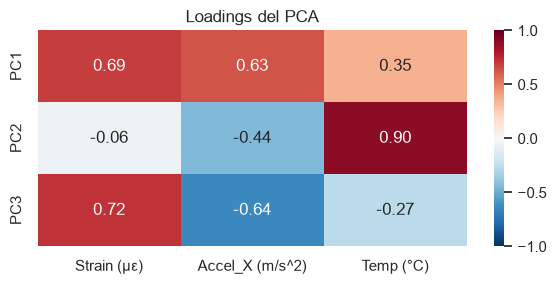

In [18]:
loadings = pd.DataFrame(pca.components_, index=pcs, columns=FEATURES_TOP)
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Loadings del PCA")
plt.tight_layout()
plt.show()

### Proyección 2D

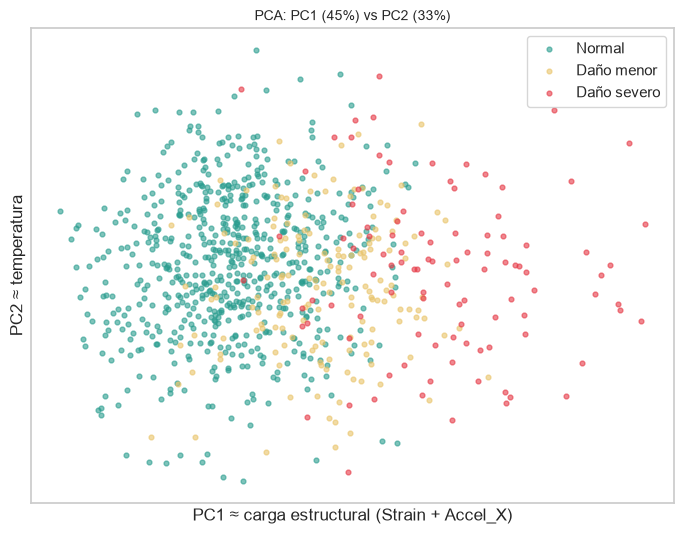

In [19]:
def scatter_clases(ax, Z, titulo):
    for clase, nombre in NOMBRES_CLASE.items():
        m = y == clase
        ax.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.6, color=PALETA_CLASES[clase], label=nombre)
    ax.set_title(titulo, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter_clases(ax, X_pca, f"PCA: PC1 ({var_ratio[0]:.0%}) vs PC2 ({var_ratio[1]:.0%})")
ax.set_xlabel("PC1 ≈ carga estructural (Strain + Accel_X)")
ax.set_ylabel("PC2 ≈ temperatura")
ax.legend()
plt.tight_layout()
plt.show()

## Kernel PCA con distintos kernels

El PCA lineal solo encuentra direcciones rectas. Kernel PCA proyecta los datos a un espacio no lineal antes de extraer componentes. Comparamos:

- `linear`: debe coincidir con el PCA.
- `poly` de grado 2 y 3.
- `rbf` con γ = 0.1, 0.5 y 2 (a mayor γ, más local es la similitud).
- `sigmoid` y `cosine`.

Para comparar las proyecciones 2D de forma objetiva usamos dos métricas. La etiqueta se usa **solo para evaluar**:

- **Silhouette** frente a la etiqueta real: qué tan separadas quedan las clases.
- **Accuracy de kNN** (k=15, validación cruzada de 5 folds) sobre las 2 componentes. Hay que compararlo con el 70.5% que se obtiene prediciendo siempre "Normal".

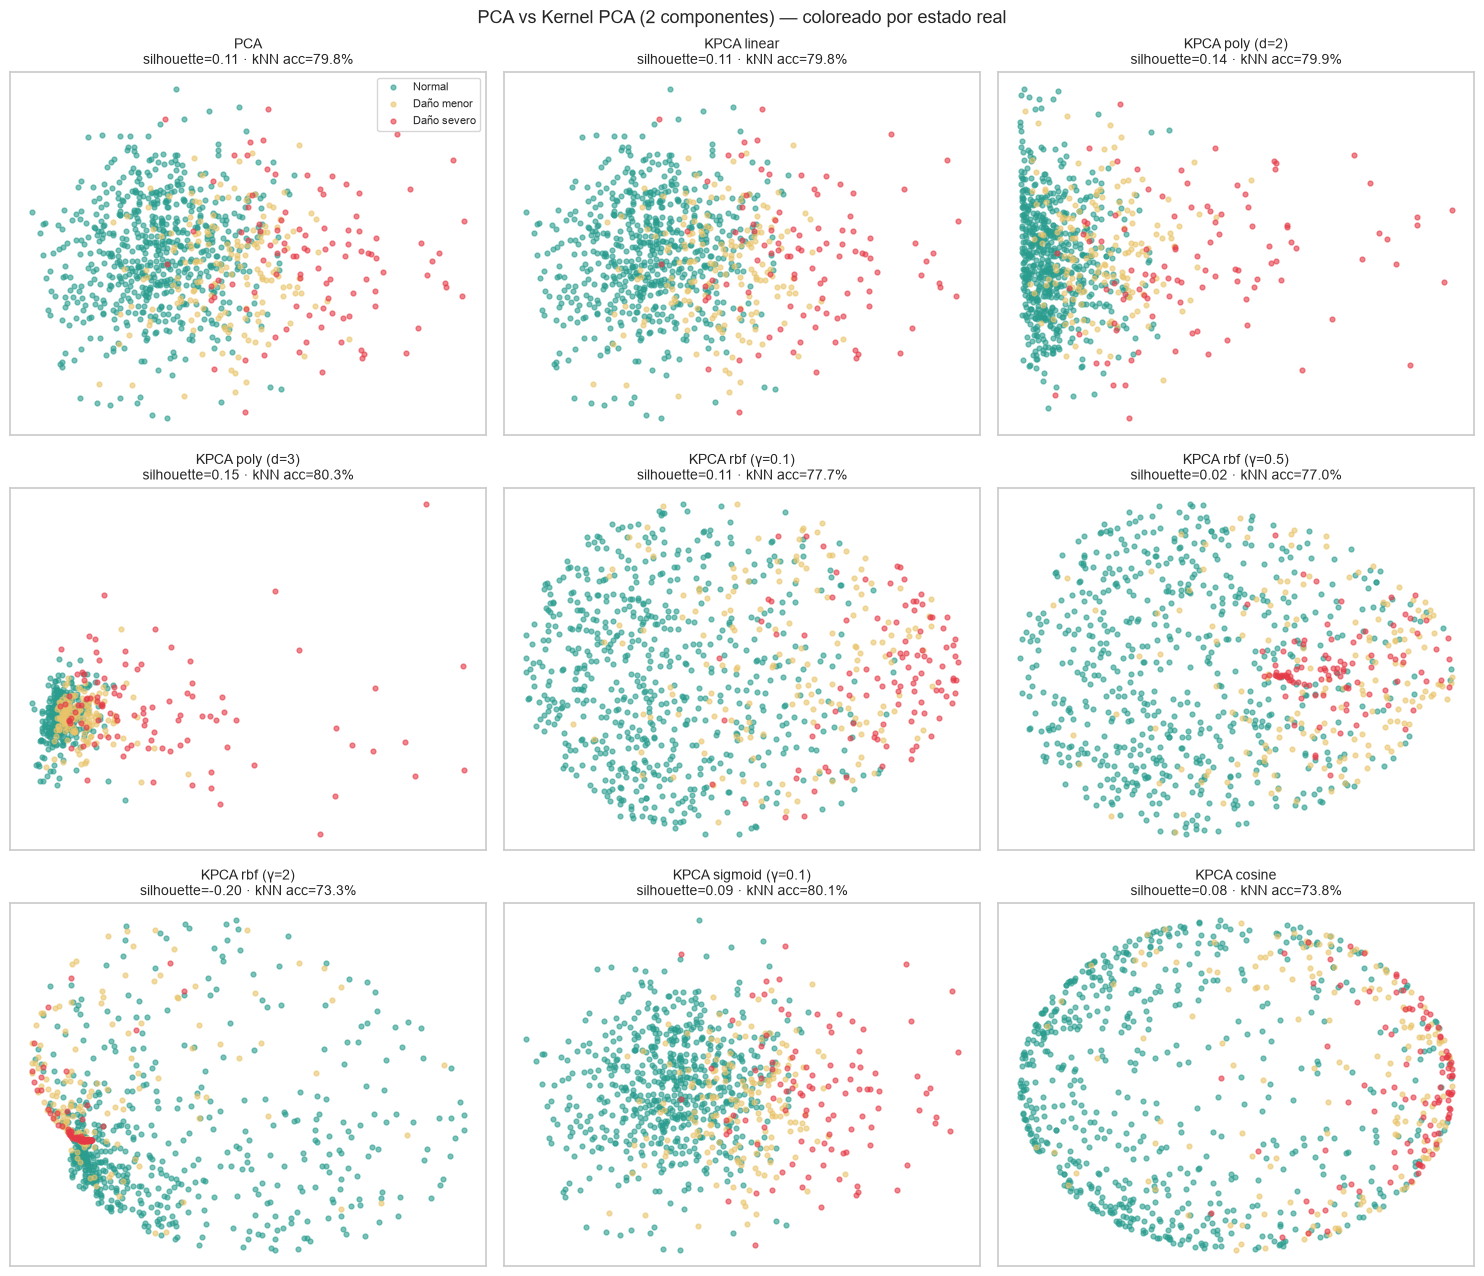

In [20]:
KERNELS = {
    "linear": dict(kernel="linear"),
    "poly (d=2)": dict(kernel="poly", degree=2),
    "poly (d=3)": dict(kernel="poly", degree=3),
    "rbf (γ=0.1)": dict(kernel="rbf", gamma=0.1),
    "rbf (γ=0.5)": dict(kernel="rbf", gamma=0.5),
    "rbf (γ=2)": dict(kernel="rbf", gamma=2),
    "sigmoid (γ=0.1)": dict(kernel="sigmoid", gamma=0.1),
    "cosine": dict(kernel="cosine"),
}
knn = KNeighborsClassifier(n_neighbors=15)

def evaluar(Z):
    return silhouette_score(Z, y), cross_val_score(knn, Z, y, cv=5).mean()

proyecciones = {"PCA": X_pca[:, :2]}
for nombre, params in KERNELS.items():
    proyecciones[f"KPCA {nombre}"] = KernelPCA(n_components=2, **params).fit_transform(X_scaled)

metricas = pd.DataFrame(
    {nombre: evaluar(Z) for nombre, Z in proyecciones.items()},
    index=["silhouette", "accuracy_knn"],
).T

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (nombre, Z) in zip(axes.flat, proyecciones.items()):
    sil, acc = metricas.loc[nombre]
    scatter_clases(ax, Z, f"{nombre}\nsilhouette={sil:.2f} · kNN acc={acc:.1%}")
axes[0, 0].legend(loc="best", fontsize=8)
plt.suptitle("PCA vs Kernel PCA (2 componentes) — coloreado por estado real", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
BASELINE = (y == 0).mean()
print(f"Baseline (predecir siempre 'Normal'): {BASELINE:.1%}")
display(metricas.sort_values("accuracy_knn", ascending=False)
        .style.format({"silhouette": "{:.3f}", "accuracy_knn": "{:.1%}"})
        .background_gradient(cmap="Greens"))

Baseline (predecir siempre 'Normal'): 70.5%


,silhouette,accuracy_knn
KPCA poly (d=3),0.153,80.3%
KPCA sigmoid (γ=0.1),0.094,80.1%
KPCA poly (d=2),0.144,79.9%
PCA,0.110,79.8%
KPCA linear,0.110,79.8%
KPCA rbf (γ=0.1),0.114,77.7%
KPCA rbf (γ=0.5),0.021,77.0%
KPCA cosine,0.082,73.8%
KPCA rbf (γ=2),-0.202,73.3%


### Efecto de γ en el kernel RBF

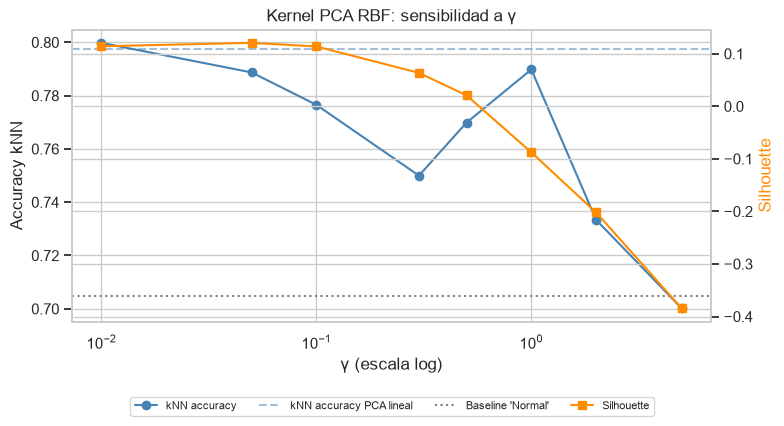

In [22]:
GAMMAS = [0.01, 0.05, 0.1, 0.3, 0.5, 1, 2, 5]
res_gamma = pd.DataFrame(
    [evaluar(KernelPCA(n_components=2, kernel="rbf", gamma=g).fit_transform(X_scaled)) for g in GAMMAS],
    index=GAMMAS, columns=["silhouette", "accuracy_knn"],
)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(GAMMAS, res_gamma["accuracy_knn"], "o-", color="steelblue", label="kNN accuracy")
ax1.axhline(metricas.loc["PCA", "accuracy_knn"], ls="--", color="steelblue", alpha=0.5, label="kNN accuracy PCA lineal")
ax1.axhline(BASELINE, ls=":", color="gray", label="Baseline 'Normal'")
ax1.set_xscale("log")
ax1.set_xlabel("γ (escala log)")
ax1.set_ylabel("Accuracy kNN")
ax2 = ax1.twinx()
ax2.plot(GAMMAS, res_gamma["silhouette"], "s-", color="darkorange", label="Silhouette")
ax2.set_ylabel("Silhouette", color="darkorange")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=4, fontsize=8)
ax1.set_title("Kernel PCA RBF: sensibilidad a γ")
plt.tight_layout()
plt.show()

### Conclusiones PCA vs Kernel PCA

**1. Seleccionar variables sí mejora el PCA.**
- Con los 3 sensores relevantes, PC1+PC2 retienen el 77% de la varianza. Con los 5 sensores era el 47%.
- PC1 combina `Strain` y `Accel_X`: es un eje de "carga estructural", y en él las tres clases se ordenan de izquierda a derecha. PC2 es básicamente `Temp`.

**2. Kernel PCA no aporta una mejora real.**
- `linear` coincide exactamente con el PCA, como debe ser.
- `poly (d=3)` y `sigmoid` quedan empatados con el PCA (~80% de kNN frente a 79.8%). La diferencia es menor que el ruido de la validación cruzada.
- `poly` solo estira la cola de daño severo; no crea separación nueva.

**3. RBF y `cosine` empeoran la proyección.**
- RBF con γ alto se vuelve demasiado local: con γ ≥ 2 la silhouette es negativa y la accuracy de kNN baja hacia el baseline del 70.5%.
- `cosine` proyecta los datos sobre una circunferencia y pierde la magnitud, que en este caso es justo la información de daño.

**En la práctica:** la frontera entre clases es casi lineal (más deformación y más vibración significan más daño). Por eso el PCA lineal sobre `Strain`, `Accel_X` y `Temp` es la opción más simple e interpretable, y rinde lo mismo que los kernels.

## Clustering no supervisado: ¿emergen los estados de daño?

Vamos a comprobar si KMeans y DBSCAN recuperan por sí solos los 3 estados de `Condition Label`. Ninguno de los dos ve la etiqueta; solo se usa al final para evaluar con dos métricas:

- **ARI (Adjusted Rand Index):** 1 = los clústeres coinciden exactamente con las clases, 0 = coincidencia al azar.
- **Tabla cruzada clase real × clúster:** muestra *qué* separa cada método.

Espacio de trabajo: el PCA de los 3 sensores seleccionados (`X_pca`).

In [23]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42

def tabla_cruzada(ax, labels, titulo):
    tabla = pd.crosstab(pd.Series(y).map(NOMBRES_CLASE), pd.Series(labels, name="Clúster"))
    tabla = tabla.reindex(NOMBRES_CLASE.values())
    tabla.columns = ["Ruido" if c == -1 else f"C{c}" for c in tabla.columns]
    sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_ylabel("Clase real")
    ax.set_title(titulo, fontsize=10)

def scatter_clusters(ax, Z, labels, titulo):
    for c in sorted(set(labels)):
        m = labels == c
        ax.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.6,
                   color="lightgray" if c == -1 else None,
                   label="Ruido" if c == -1 else f"C{c}")
    ax.set_xlabel("PC1 (carga estructural)")
    ax.set_ylabel("PC2 (temperatura)")
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)

### KMeans en PC1–PC2

Empezamos por el enfoque estándar: las 2 primeras componentes, que retienen el 77% de la varianza. Elegimos `k` con el método del codo y el Silhouette.

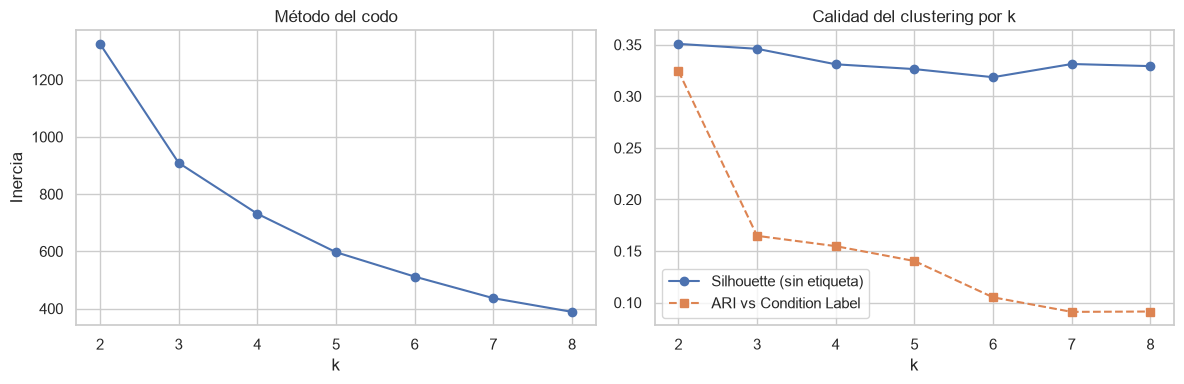

In [24]:
X_pca_input = X_pca[:, :2]
K_MIN, K_MAX = 2, 8
ks = range(K_MIN, K_MAX + 1)
inercias, siluetas, aris = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca_input)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_pca_input, km.labels_))
    aris.append(adjusted_rand_score(y, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inercias, "o-")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[1].plot(ks, siluetas, "o-", label="Silhouette (sin etiqueta)")
axes[1].plot(ks, aris, "s--", label="ARI vs Condition Label")
axes[1].set_title("Calidad del clustering por k")
axes[1].set_xlabel("k")
axes[1].legend()
plt.tight_layout()
plt.show()

El codo no es nítido: la inercia baja de forma suave, que es lo esperable en una nube de puntos sin grupos separados. Como sabemos que hay 3 estados, probamos `K_OPT = 3`.

KMeans k=3 en PC1–PC2 → Silhouette=0.346 | ARI=0.165


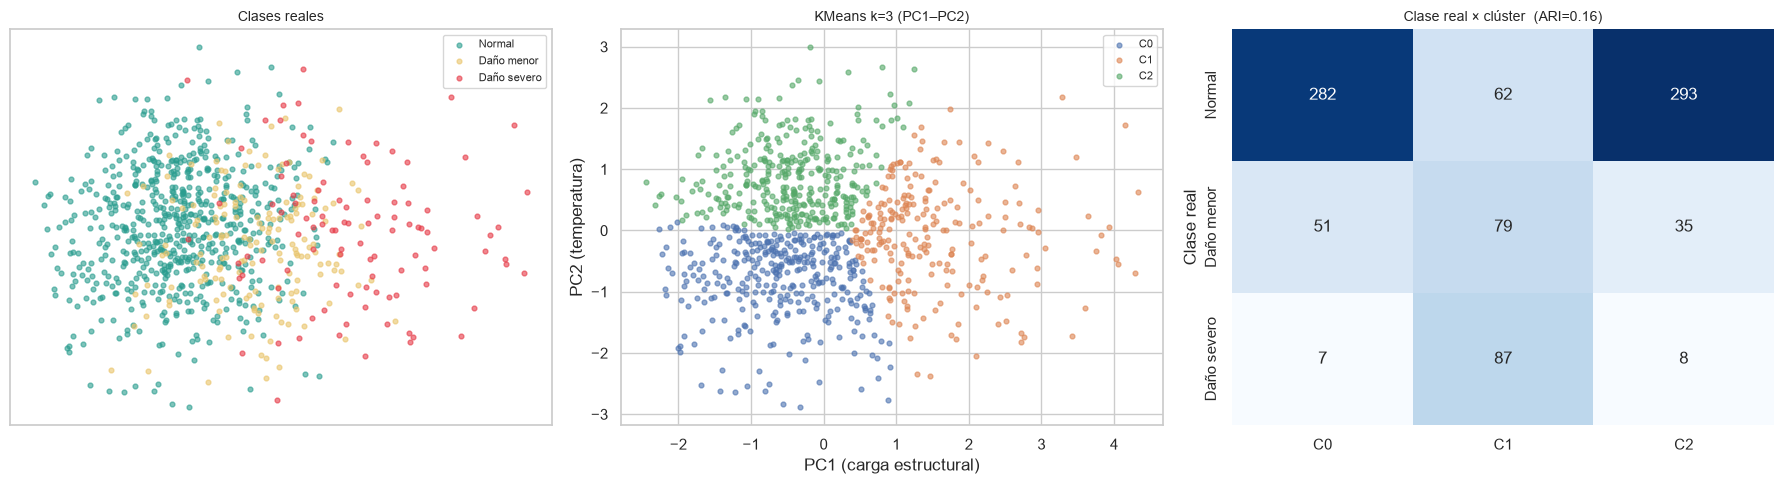

In [25]:
K_OPT = 3
km_2d = KMeans(n_clusters=K_OPT, n_init=10, random_state=RANDOM_STATE)
labels_km_2d = km_2d.fit_predict(X_pca_input)
sil_km_2d = silhouette_score(X_pca_input, labels_km_2d)
ari_km_2d = adjusted_rand_score(y, labels_km_2d)
print(f"KMeans k={K_OPT} en PC1–PC2 → Silhouette={sil_km_2d:.3f} | ARI={ari_km_2d:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_clases(axes[0], X_pca_input, "Clases reales")
axes[0].legend(fontsize=8)
scatter_clusters(axes[1], X_pca_input, labels_km_2d, f"KMeans k={K_OPT} (PC1–PC2)")
tabla_cruzada(axes[2], labels_km_2d, f"Clase real × clúster  (ARI={ari_km_2d:.2f})")
plt.tight_layout()
plt.show()

**Resultado:** KMeans corta la nube también en *vertical*. La clase Normal queda repartida entre dos clústeres según la temperatura (PC2).

Tiene sentido: KMeans busca grupos compactos en cualquier dirección, y PC2 tiene casi tanta varianza como PC1. Pero la temperatura no indica daño.

**Corrección:** usar solo **PC1**, el eje de carga estructural (`Strain` + `Accel_X`), que es donde se ordenan los estados de daño.

KMeans k=3 solo en PC1 → Silhouette=0.531 | ARI=0.265  (antes 0.165)


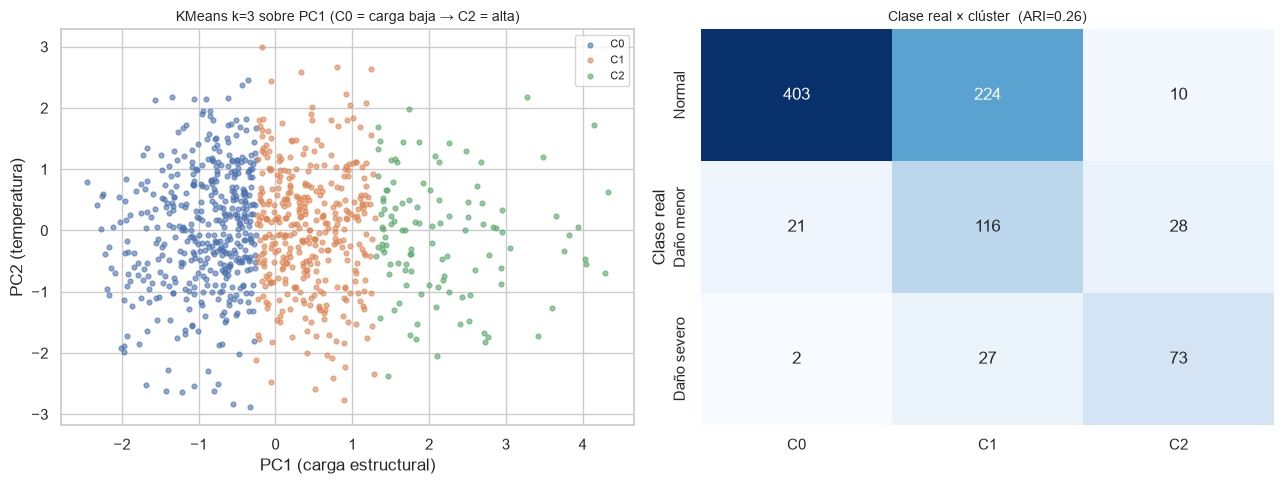

In [26]:
labels_km = KMeans(n_clusters=K_OPT, n_init=10, random_state=RANDOM_STATE).fit_predict(X_pca[:, :1])
sil_km = silhouette_score(X_pca[:, :1], labels_km)
ari_km = adjusted_rand_score(y, labels_km)
print(f"KMeans k={K_OPT} solo en PC1 → Silhouette={sil_km:.3f} | ARI={ari_km:.3f}  (antes {ari_km_2d:.3f})")

# Renumerar los clústeres por la media de PC1 para leerlos como bajo / medio / alto
orden = pd.Series(X_pca[:, 0]).groupby(labels_km).mean().sort_values().index
labels_km = pd.Series(labels_km).map({c: i for i, c in enumerate(orden)}).values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_clusters(axes[0], X_pca_input, labels_km, f"KMeans k={K_OPT} sobre PC1 (C0 = carga baja → C2 = alta)")
tabla_cruzada(axes[1], labels_km, f"Clase real × clúster  (ARI={ari_km:.2f})")
plt.tight_layout()
plt.show()

### DBSCAN

DBSCAN agrupa zonas densas y marca como **ruido (-1)** los puntos aislados. Aquí lo usamos sobre las 3 componentes (toda la información de los 3 sensores).

Para elegir `eps` usamos el gráfico de *k-distancias*: la distancia de cada punto a su `MIN_SAMPLES`-ésimo vecino, ordenada de menor a mayor. El codo de esa curva es un buen `eps`.

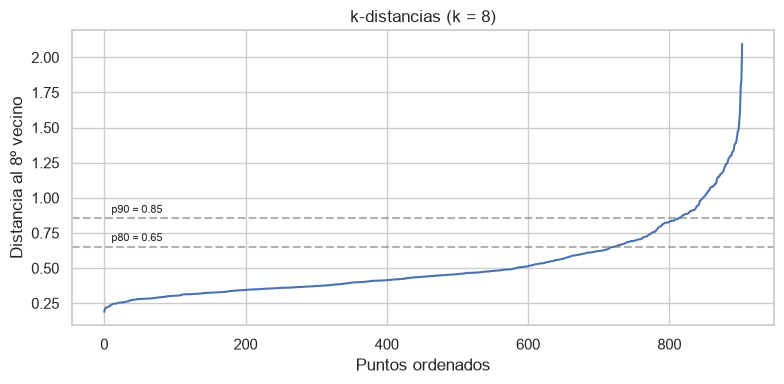

In [27]:
X_db = X_pca
MIN_SAMPLES = 8
dist_k = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_db).kneighbors(X_db)[0][:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dist_k)
for p in (80, 90):
    v = np.percentile(dist_k, p)
    ax.axhline(v, ls="--", color="gray", alpha=0.6)
    ax.annotate(f"p{p} = {v:.2f}", (10, v), textcoords="offset points", xytext=(0, 4), fontsize=8)
ax.set_title(f"k-distancias (k = {MIN_SAMPLES})")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al {MIN_SAMPLES}º vecino")
plt.tight_layout()
plt.show()

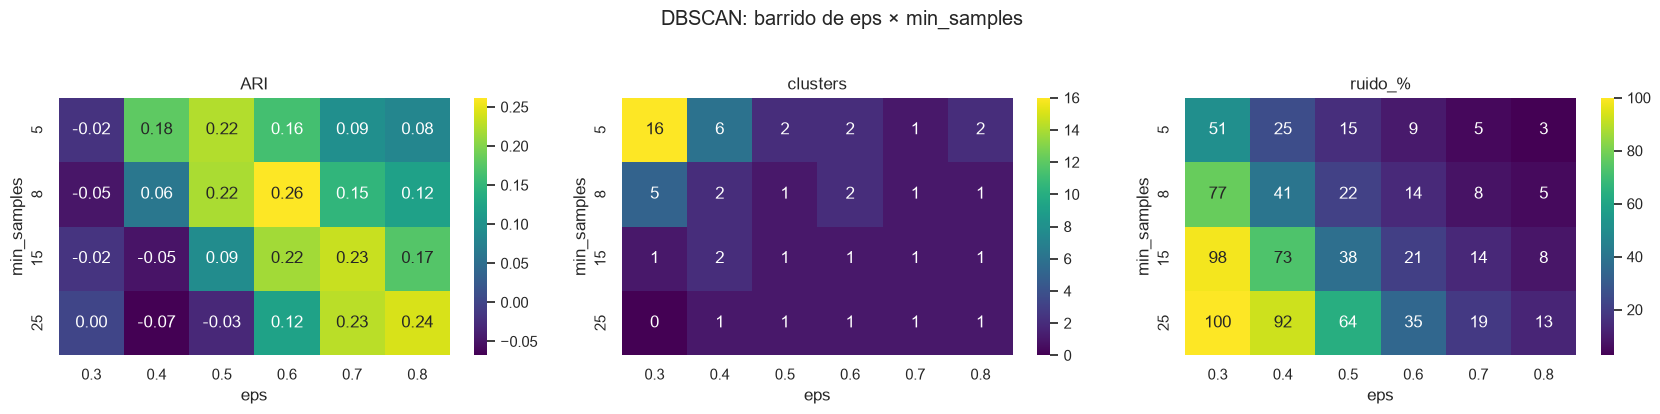

In [28]:
EPS_GRID = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
MS_GRID = [5, 8, 15, 25]
filas = []
for eps in EPS_GRID:
    for ms in MS_GRID:
        l = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_db)
        filas.append({"eps": eps, "min_samples": ms,
                      "clusters": len(set(l)) - (-1 in l),
                      "ruido_%": (l == -1).mean() * 100,
                      "ARI": adjusted_rand_score(y, l)})
grid_db = pd.DataFrame(filas)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col, fmt in zip(axes, ["ARI", "clusters", "ruido_%"], [".2f", "d", ".0f"]):
    sns.heatmap(grid_db.pivot(index="min_samples", columns="eps", values=col),
                annot=True, fmt=fmt, cmap="viridis", ax=ax)
    ax.set_title(col)
plt.suptitle("DBSCAN: barrido de eps × min_samples", y=1.03)
plt.tight_layout()
plt.show()

En ningún punto del barrido aparecen 3 clústeres limpios. La nube es **una sola zona densa**, y DBSCAN la trata como un único grupo. Lo que sí separa bien es el **ruido**: los puntos de la periferia.

Elegimos `EPS = 0.6` (cerca del percentil 80 de k-distancias) y `MIN_SAMPLES = 8`, la combinación con mayor ARI.

DBSCAN eps=0.6, min_samples=8 → 2 clústeres | ruido=125 (13.8%) | Silhouette (sin ruido)=0.269 | ARI=0.262


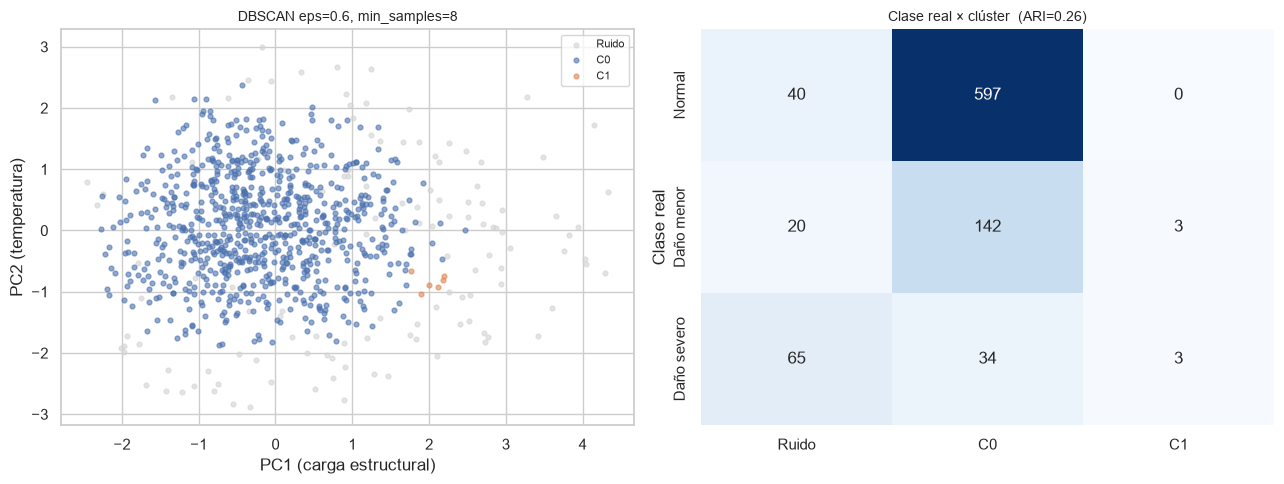

Daño severo marcado como ruido: 65/102 (64%)
Del ruido, es daño severo: 52%  (vs 11% en el dataset)


In [29]:
EPS = 0.6
labels_db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(X_db)
n_clusters_db = len(set(labels_db)) - (-1 in labels_db)
es_ruido = labels_db == -1
sil_db = silhouette_score(X_db[~es_ruido], labels_db[~es_ruido]) if n_clusters_db > 1 else np.nan
ari_db = adjusted_rand_score(y, labels_db)
print(f"DBSCAN eps={EPS}, min_samples={MIN_SAMPLES} → {n_clusters_db} clústeres | "
      f"ruido={es_ruido.sum()} ({es_ruido.mean():.1%}) | Silhouette (sin ruido)={sil_db:.3f} | ARI={ari_db:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_clusters(axes[0], X_db, labels_db, f"DBSCAN eps={EPS}, min_samples={MIN_SAMPLES}")
tabla_cruzada(axes[1], labels_db, f"Clase real × clúster  (ARI={ari_db:.2f})")
plt.tight_layout()
plt.show()

sev = y == 2
print(f"Daño severo marcado como ruido: {(es_ruido & sev).sum()}/{sev.sum()} ({(es_ruido & sev).sum() / sev.sum():.0%})")
print(f"Del ruido, es daño severo: {sev[es_ruido].mean():.0%}  (vs {sev.mean():.0%} en el dataset)")

### Comparativa

,Silhouette,ARI,NMI
Método,,,
KMeans k=3 (PC1–PC2),0.346,0.165,0.178
KMeans k=3 (PC1),0.531,0.265,0.276
DBSCAN eps=0.6 (PC1–PC3),0.269,0.262,0.171


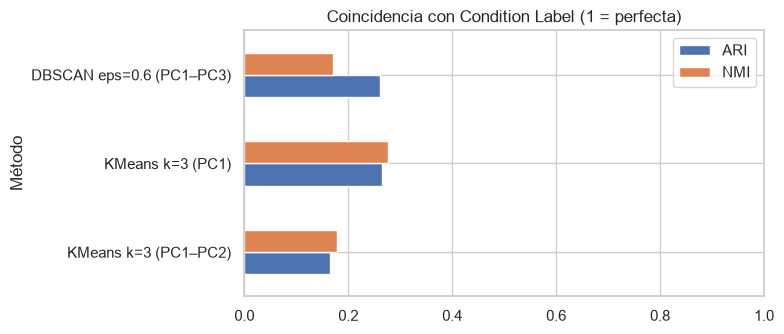

In [30]:
resultados = pd.DataFrame([
    {"Método": f"KMeans k={K_OPT} (PC1–PC2)", "Silhouette": sil_km_2d, "ARI": ari_km_2d,
     "NMI": normalized_mutual_info_score(y, labels_km_2d)},
    {"Método": f"KMeans k={K_OPT} (PC1)", "Silhouette": sil_km, "ARI": ari_km,
     "NMI": normalized_mutual_info_score(y, labels_km)},
    {"Método": f"DBSCAN eps={EPS} (PC1–PC3)", "Silhouette": sil_db, "ARI": ari_db,
     "NMI": normalized_mutual_info_score(y, labels_db)},
]).set_index("Método")
display(resultados.style.format("{:.3f}"))

ax = resultados[["ARI", "NMI"]].plot.barh(figsize=(8, 3.5))
ax.set_xlim(0, 1)
ax.set_title("Coincidencia con Condition Label (1 = perfecta)")
plt.tight_layout()
plt.show()

### Conclusiones del clustering

**1. El aprendizaje no supervisado no replica las 3 clases, pero sí detecta el daño parcialmente.**
- El mejor ARI es ≈ 0.26–0.27, lejos de 1. Los estados de daño **no forman grupos separados**: son un continuo dentro de una sola nube.

**2. Elegir bien el espacio importa más que el algoritmo.**
- KMeans en PC1–PC2 parte la clase Normal por temperatura (ARI ≈ 0.17).
- Restringido a PC1 (carga estructural), los clústeres pasan a leerse como carga baja / media / alta y el ARI sube a ≈ 0.27.
- Aun así, C1 (carga media) mezcla Normal con Daño menor. La frontera entre esos dos estados es la más difusa.

**3. DBSCAN funciona mejor como detector de anomalías que como clasificador.**
- Encuentra un único núcleo denso: la operación normal.
- Los puntos que marca como ruido están muy enriquecidos en daño severo: ~52% del ruido, frente a ~11% en el dataset. Además captura ~64% de las lecturas de daño severo.
- En obra, esto sirve como sistema de alerta temprana ("esta lectura se sale del patrón habitual"), que luego se confirma con inspección.

**En resumen:**
- Para *replicar* las etiquetas hace falta aprendizaje supervisado: la sección anterior dio ~80% de accuracy con kNN.
- El clustering aporta otra cosa: sin ninguna etiqueta, identifica el eje de daño (PC1) y aísla las lecturas anómalas.